# 13 Modern Causal Frontiers: Synthetic Difference-in-Differences and Matrix Completion

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/06-Econometrics/13_Modern_Causal_Frontiers_SDID.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=06-Econometrics/13_Modern_Causal_Frontiers_SDID.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)
## The Lens: Building a Credible Counterfactual When Parallel Trends Are Too Crude
Difference-in-differences (DiD) is persuasive when untreated units reveal the path the treated units would have followed. Synthetic control is persuasive when a weighted combination of controls reproduces the treated pre-period. Synthetic difference-in-differences (SDID) combines those ideas: it chooses unit weights and time weights to improve pre-treatment balance, then estimates a DiD-style contrast that retains an intercept correction.

This notebook focuses on the mechanism rather than presenting a package call as proof. We construct a latent-factor panel with known treatment effect, solve constrained ridge problems for unit and time weights, and compare classical DiD with an SDID-style estimator. The exercise is intentionally transparent: the implementation is an educational reconstruction of the weighting logic, not a substitute for the complete inference machinery in production SDID libraries. We close with matrix completion, where untreated potential outcomes are modeled as a low-rank panel, and with the diagnostics that determine whether either method has enough pre-treatment information to be credible.

### Learning Objectives
- **Explain** how SDID blends synthetic-control balancing with DiD intercept correction.
- **Solve** simplex-constrained ridge problems for unit and time weights.
- **Compare** estimators in a panel where the true effect is known.
- **Relate** SDID to low-rank matrix completion and modern sensitivity analysis.

### Prerequisites
- `08_Difference_in_Differences.ipynb`: potential-outcomes DiD and staggered adoption.
- `07_Synthetic_Control_Methods.ipynb`: synthetic-control weights and placebo logic.
- `../02-Numerical-Methods/05_Optimization.ipynb`: constrained optimization.
* **Learning-path prerequisite:** [`12_Panel_Data_Methods.ipynb`](12_Panel_Data_Methods.ipynb)


> **Learning path:** Building on [`12_Panel_Data_Methods.ipynb`](12_Panel_Data_Methods.ipynb); this notebook closes the current track.


## Table of Contents

1. [The SDID estimand](#sdid-estimand)
2. [Unit and time balancing](#unit-time-balancing)
3. [Synthetic panel experiment](#synthetic-panel)
4. [Estimator comparison](#estimator-comparison)
5. [Matrix completion and sensitivity](#matrix-completion)
6. [Exercises](#exercises)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "figure.figsize": (10, 6), "figure.dpi": 120})
np.set_printoptions(suppress=True, precision=5, linewidth=120)

from scipy.optimize import minimize


<a id="sdid-estimand"></a>
## 1. The SDID Estimand

Let $Y_{it}$ be a balanced panel, with treated units observed after time $T_0$. Classical DiD gives equal weight to control units and pre-periods. SDID instead estimates nonnegative simplex weights $\omega_i$ for controls and $\lambda_t$ for pre-periods, then forms an intercept-corrected contrast. A transparent two-group version is

$$\hat\tau = \left(\bar Y^{tr}_{post}-\omega'\bar Y^{co}_{post}\right)
-\left(\lambda'\bar Y^{tr}_{pre}-\omega'Y^{co}_{pre}\lambda\right).$$

If uniform weights are used, this collapses toward ordinary DiD. If pre-treatment trajectories are highly informative, the learned weights make the counterfactual more local to the treated path.

**Dimension notes:** balanced panel $Y_{it}$ over $N$ units and $T$ periods; unit weights $\omega \in \Delta_{N_0 - 1}$ over the $N_0$ controls, time weights $\lambda \in \Delta_{T_0 - 1}$ over the $T_0$ pre-periods; $\hat{\tau}$ is a scalar.

<a id="unit-time-balancing"></a>
## 2. Unit and Time Balancing

We use ridge-regularized simplex problems. Unit weights solve

$$\min_{\omega\ge 0,\;\mathbf{1}'\omega=1}
\|Y_{co,pre}'\omega-\bar Y_{tr,pre}\|_2^2+\zeta_\omega\|\omega\|_2^2.$$

Time weights reverse the regression: pre-period columns are combined to reproduce each control unit's average post-period outcome,

$$\min_{\lambda\ge0,\;\mathbf{1}'\lambda=1}
\|Y_{co,pre}\lambda-\bar Y_{co,post}\|_2^2+\zeta_\lambda\|\lambda\|_2^2.$$

The ridge terms prevent a near-perfect but fragile match from concentrating all weight on one unit or date.

**Dimension notes:** $Y_{co,pre} \in \mathbb{R}^{T_0 \times N_0}$ is the pre-period control block, $\bar{Y}_{tr,pre} \in \mathbb{R}^{T_0}$ the treated unit's pre-period path; $\omega \in \Delta_{N_0-1}$ and $\lambda \in \Delta_{T_0-1}$ sit on simplices, and the ridge penalties $\zeta_\omega, \zeta_\lambda > 0$ are scalars.

In [2]:
def simplex_ridge(A, b, ridge=1e-3):
    """Solve min ||A @ w - b||^2 + ridge*||w||^2 on the probability simplex."""
    A, b = np.asarray(A, float), np.asarray(b, float)
    n = A.shape[1]
    objective = lambda w: float(np.sum((A @ w - b) ** 2) + ridge * np.sum(w**2))
    gradient = lambda w: 2 * (A.T @ (A @ w - b) + ridge * w)
    result = minimize(
        objective,
        np.full(n, 1 / n),
        jac=gradient,
        bounds=[(0.0, 1.0)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1.0, "jac": lambda w: np.ones(n)},
        method="SLSQP",
        options={"ftol": 1e-12, "maxiter": 2_000},
    )
    if not result.success:
        raise RuntimeError(result.message)
    return result.x


<a id="synthetic-panel"></a>
## 3. Synthetic Panel Experiment

The untreated outcome contains unit effects, time effects, and a latent factor whose loading differs across units. Treated units are selected partly on that loading, so equal-weight controls have imperfect pre-trends. The true treatment effect is known and constant after adoption.


In [3]:
n_units, n_periods, n_treated, t0 = 40, 24, 6, 16
true_tau = 2.0
time = np.arange(n_periods)
unit_fe = rng.normal(scale=1.0, size=n_units)
loadings = rng.normal(size=n_units)
factor = 0.08 * time + 0.8 * np.sin(time / 4)
time_fe = 0.04 * time
noise = rng.normal(scale=0.25, size=(n_units, n_periods))
y0 = unit_fe[:, None] + time_fe[None, :] + loadings[:, None] * factor[None, :] + noise

treated_idx = np.argsort(loadings)[-n_treated:]
control_idx = np.setdiff1d(np.arange(n_units), treated_idx)
treated = np.zeros((n_units, n_periods), dtype=bool)
treated[np.ix_(treated_idx, np.arange(t0, n_periods))] = True
y = y0 + true_tau * treated

pre, post = np.arange(t0), np.arange(t0, n_periods)
tr_pre = y[np.ix_(treated_idx, pre)].mean(axis=0)
co_pre = y[np.ix_(control_idx, pre)]
co_post_mean = y[np.ix_(control_idx, post)].mean(axis=1)

omega = simplex_ridge(co_pre.T, tr_pre, ridge=0.05)
lambda_pre = simplex_ridge(co_pre, co_post_mean, ridge=0.05)
assert np.isclose(omega.sum(), 1.0) and np.isclose(lambda_pre.sum(), 1.0)


<a id="estimator-comparison"></a>
## 4. Estimator Comparison

The pre-fit error is reported alongside the treatment effect. An estimator that happens to land near the truth but cannot reproduce the pre-period should not be treated as validated.


In [4]:
treated_pre_mean = y[np.ix_(treated_idx, pre)].mean()
treated_post_mean = y[np.ix_(treated_idx, post)].mean()
control_pre_mean = y[np.ix_(control_idx, pre)].mean()
control_post_mean = y[np.ix_(control_idx, post)].mean()
did = (treated_post_mean - treated_pre_mean) - (control_post_mean - control_pre_mean)

tr_post = y[np.ix_(treated_idx, post)].mean(axis=0)
weighted_control_post = omega @ y[np.ix_(control_idx, post)].mean(axis=1)
weighted_treated_pre = lambda_pre @ tr_pre
weighted_control_pre = omega @ (co_pre @ lambda_pre)
sdid_style = float(tr_post.mean() - weighted_control_post - (weighted_treated_pre - weighted_control_pre))

pre_fit_uniform = float(np.sqrt(np.mean((co_pre.mean(axis=0) - tr_pre) ** 2)))
pre_fit_weighted = float(np.sqrt(np.mean((omega @ co_pre - tr_pre) ** 2)))
summary = pd.DataFrame({
    "estimate": [true_tau, did, sdid_style],
    "absolute_error": [0.0, abs(did - true_tau), abs(sdid_style - true_tau)],
}, index=["truth", "classical DiD", "SDID-style"])
display(summary)
print(f"pre-period RMSE: uniform={pre_fit_uniform:.4f}, weighted={pre_fit_weighted:.4f}")
assert pre_fit_weighted <= pre_fit_uniform + 1e-8


,estimate,absolute_error
truth,2.000000,0.000000
classical DiD,1.923450,0.076550
SDID-style,2.099322,0.099322


pre-period RMSE: uniform=0.9890, weighted=0.1524


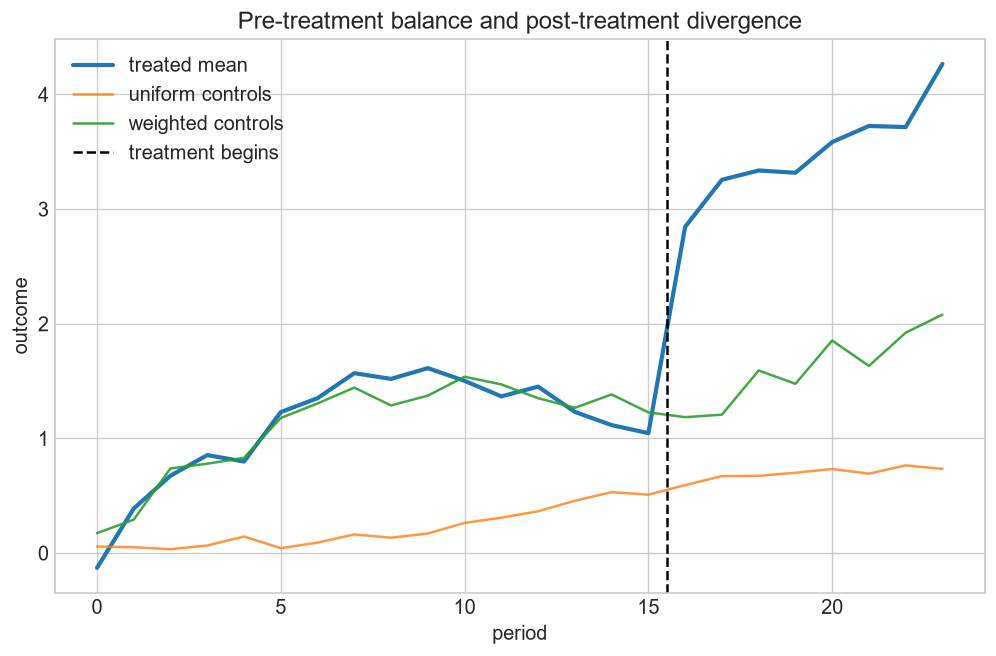

In [5]:
fig, ax = plt.subplots()
tr_path = y[treated_idx].mean(axis=0)
co_uniform = y[control_idx].mean(axis=0)
co_weighted = omega @ y[control_idx]
ax.plot(time, tr_path, label="treated mean", lw=2.5)
ax.plot(time, co_uniform, label="uniform controls", alpha=0.8)
ax.plot(time, co_weighted, label="weighted controls", alpha=0.9)
ax.axvline(t0 - 0.5, color="black", ls="--", label="treatment begins")
ax.set(xlabel="period", ylabel="outcome", title="Pre-treatment balance and post-treatment divergence")
ax.legend()
plt.show()


<a id="matrix-completion"></a>
## 5. Matrix Completion and Sensitivity

Synthetic weighting is one way to exploit low-dimensional structure. Matrix-completion approaches instead posit

$$Y_{it}(0)=\alpha_i+\gamma_t+L_{it}+\varepsilon_{it},$$

where $L$ is low rank and is estimated from untreated entries with nuclear-norm or factor regularization. The counterfactual is the completed treated-post block. This is most useful when many units and periods reveal stable latent factors.

Neither method repairs a design with no credible untreated information. Modern DiD work therefore complements flexible counterfactual models with **design diagnostics and sensitivity analysis**. In particular, Rambachan-Roth style analyses ask how much post-treatment deviation from extrapolated pre-trends is required to overturn a result. The right workflow separates (1) fit of untreated outcomes, (2) treatment-effect estimation, and (3) sensitivity to violations that the data cannot rule out.


## Key Equations

These relations are collected from the derivations above as a review map. Their assumptions and derivations remain part of the result; this box is not a substitute for them.

**1. Core relation**

$$\hat\tau = \left(\bar Y^{tr}_{post}-\omega'\bar Y^{co}_{post}\right) -\left(\lambda'\bar Y^{tr}_{pre}-\omega'Y^{co}_{pre}\lambda\right).$$

**2. Core relation**

$$\min_{\omega\ge 0,\;\mathbf{1}'\omega=1} \|Y_{co,pre}'\omega-\bar Y_{tr,pre}\|_2^2+\zeta_\omega\|\omega\|_2^2.$$

**3. Core relation**

$$\min_{\lambda\ge0,\;\mathbf{1}'\lambda=1} \|Y_{co,pre}\lambda-\bar Y_{co,post}\|_2^2+\zeta_\lambda\|\lambda\|_2^2.$$

**4. Core relation**

$$Y_{it}(0)=\alpha_i+\gamma_t+L_{it}+\varepsilon_{it},$$

**Dimension notes:** weights $\omega \in \Delta_{N_0-1}$ and $\lambda \in \Delta_{T_0-1}$; every barred quantity is a conformable vector of period or unit averages; $\hat{\tau}$ is scalar.

## Exercises

**1. Weight geometry (Conceptual):** Explain the roles of the simplex constraint and ridge penalty. What does a single control receiving weight one tell you about overlap and extrapolation risk?

**2. Selection strength (Applied):** Change the rule that selects treated units from random assignment to progressively stronger selection on the latent loading. Compare classical DiD and SDID-style error over at least 100 simulated panels.

**3. Low-rank counterfactual (Challenge):** Implement a rank-$k$ factor completion using only untreated observations. Choose rank using pre-treatment validation, estimate the treated-post counterfactual, and compare its bias with the weighting estimator.

**Failure analysis (Challenge):** SDID places all unit weight on one control, pre-fit is perfect, but placebo gaps are huge. Diagnose overfitting with too-small ridge penalties, repair with the recommended $\zeta$ regularization and unit-time balancing checks, and report placebo-based standard errors.

## Economic Interpretation: Balancing units and time

Synthetic Difference-in-Differences treats identification as a two-sided balancing problem. Unit weights construct a control combination that resembles treated units before treatment, while time weights emphasize pre-periods that best predict the post-period contrast. Economically, the estimator relaxes the idea that one untreated average or one uniform pre-period trend must represent the counterfactual; it instead asks which comparison units and which historical periods carry the most credible counterfactual information under the maintained design assumptions.


## Summary & Key Takeaways

- SDID improves on equal-weight DiD by learning both comparison-unit and pre-period weights while retaining an intercept correction.
- Weight concentration and pre-fit are diagnostics, not cosmetic outputs.
- Matrix completion attacks the same counterfactual problem through low-rank structure rather than convex weighting.
- Flexible counterfactual fitting does not eliminate the need for causal assumptions or sensitivity analysis.


## References & Further Reading

- Arkhangelsky, D., Athey, S., Hirshberg, D. A., Imbens, G. W. & Wager, S. (2021). Synthetic difference-in-differences. *American Economic Review*, 111(12), 4088–4118.
- Athey, S., Bayati, M., Doudchenko, N., Imbens, G. & Khosravi, K. (2021). Matrix completion methods for causal panel data models. *Journal of the American Statistical Association*, 116(536), 1716–1730.
- Rambachan, A. & Roth, J. (2023). A more credible approach to parallel trends. *Review of Economic Studies*, 90(5), 2555–2591.
